# Interferometric Scattering Microscopy (iSCAT)

The propagators of `psf_generator` model the **focusing** path of a microscope: a pupil function is turned into
the field around the focus. Imaging a nanoparticle needs the reverse, **detection** path, plus a model of what
the particle does to the light. This notebook walks through the classes that provide both.

| class | module | role |
|---|---|---|
| `Particle` | `psf_generator.modalities` | the sample: a Rayleigh scatterer given by its radius and permittivity |
| `SphericalDipoleImager`, `CartesianDipoleImager` | `psf_generator.imaging` | the detection path: the image of a radiating dipole |
| `ISCATMicroscope`, `COBRIMicroscope`, `DarkFieldMicroscope` | `psf_generator.modalities` | the modality: illumination + sample + detection = the recorded image |

In iSCAT the particle is illuminated through the objective and the light it scatters interferes on the camera
with the illumination reflected at the coverslip. The camera records

$$I(\boldsymbol{\rho}) = \left|\mathbf{E}^{\mathrm{ref}} + \mathbf{E}^{\mathrm{sca}}(\boldsymbol{\rho})\right|^{2},
\qquad
C(\boldsymbol{\rho}) = \frac{I - |\mathbf{E}^{\mathrm{ref}}|^{2}}{|\mathbf{E}^{\mathrm{ref}}|^{2}},$$

where $C$ is the interferometric contrast, or interferometric PSF (iPSF) -- what an iSCAT experiment measures
after dividing by a background image.

**Contents**

1. the building blocks: `Particle`, the dipole imagers, `ISCATMicroscope`
2. anatomy of an image: background, dark field and interference
3. defocus: scanning the focus and moving the particle
4. simpler models of the detection path, and how they change the PSF
5. the other coherent modalities: COBRI, dark field, mass photometry
6. saving the parameters

The physics and the sign conventions are derived in the theory page *Imaging a Dipole: the Detection Path*
(`docs/src/theory/imaging.md`); `demos/scripts/iscat_demo.py` covers the same ground as a plain script.

In [1]:
import os
import tempfile
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from psf_generator.imaging import CartesianDipoleImager, SphericalDipoleImager
from psf_generator.modalities import (
    COBRIMicroscope,
    DarkFieldMicroscope,
    ISCATMicroscope,
    Modality,
    Particle,
)
from psf_generator.propagators import ScalarSphericalPropagator, VectorialSphericalPropagator

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 10, 'font.size': 9})

In [2]:
def show_maps(images, titles, x, cmap='RdBu_r', colorbar_label=None, suptitle=None, vlim=None, zoom=None):
    """Show a row of images that share a colour scale; `x` is the image grid in nanometer, `zoom` a half-width
    of the displayed field of view in micrometer."""
    images = [np.asarray(image) for image in images]
    if vlim is None:
        limit = max(float(np.abs(image).max()) for image in images)
        vlim = (-limit, limit) if cmap == 'RdBu_r' else (0.0, limit)
    extent = np.array([x[0], x[-1], x[-1], x[0]]) / 1e3  # micrometer
    fig, axes = plt.subplots(1, len(images), figsize=(2.1 * len(images) + 1.4, 2.7),
                             constrained_layout=True, squeeze=False)
    for ax, image, title in zip(axes[0], images, titles):
        handle = ax.imshow(image, extent=extent, cmap=cmap, vmin=vlim[0], vmax=vlim[1])
        ax.set_title(title)
        ax.set_xlabel('x (µm)')
    for ax in axes[0, 1:]:
        ax.set_yticklabels([])
    if zoom is not None:
        for ax in axes[0]:
            ax.set_xlim(-zoom, zoom), ax.set_ylim(zoom, -zoom)
    axes[0, 0].set_ylabel('y (µm)')
    fig.colorbar(handle, ax=axes, label=colorbar_label, shrink=0.9)
    if suptitle is not None:
        fig.suptitle(suptitle)
    plt.show()

## 1. The building blocks

### 1.1 The sample: `Particle`

A `Particle` is a Rayleigh scatterer -- a sphere much smaller than the wavelength -- described by its radius and
its complex permittivity (or refractive index). In a medium of index $n_m$ it has the Clausius-Mossotti
polarizability $\alpha = 4\pi a^{3}(\epsilon_p - \epsilon_m)/(\epsilon_p + 2\epsilon_m)$ in nm³, so an incident
field induces the dipole $\mathbf{p} = k_m^{2}\alpha\,\mathbf{E}_{\mathrm{inc}}/4\pi$ that the imager propagates
to the camera. `Particle.from_mass` builds the particle of a given mass, the natural input for mass photometry.

In [3]:
gold = Particle(radius=15.0, permittivity=-3.7328 + 2.7725j)      # 30 nm gold at 517.5 nm (Johnson & Christy)
protein = Particle.from_mass(mass=100.0, density=1.35, refractive_index=1.59)   # 100 kDa protein

for name, particle in [('30 nm gold', gold), ('100 kDa protein', protein)]:
    print(f'{name:<16} radius {particle.radius:5.1f} nm   '
          f'alpha(n=1.33) = {particle.polarizability(1.33):.4g} nm^3   '
          f'sigma_sca = {particle.scattering_cross_section(517.5, 1.33):.3g} nm^2')

30 nm gold       radius  15.0 nm   alpha(n=1.33) = 4.809e+04+8.078e+04j nm^3   sigma_sca = 31.9 nm^2
100 kDa protein  radius   3.1 nm   alpha(n=1.33) = 46.18+0j nm^3   sigma_sca = 7.69e-06 nm^2


### 1.2 The detection path: the dipole imagers

A dipole imager computes the image of a dipole radiating in the sample, through the three layers of the sample
(medium $n_s$, coverslip $n_g$, immersion $n_i$), the aplanatic objective and the tube lens:

```python
imager.compute_image(dipole=(p_x, p_y, p_z), positions=(x_p, y_p, z_p))   # (n_positions, 3, n_pix, n_pix)
```

* `positions` are in nanometer, `z_p` being the **height of the dipole above the coverslip**; a list of
  positions is computed in one batch (all the heights share the same pupil).
* `z_focus` is a parameter of the *imager*: the depth of the focal plane in the sample. A dipole at
  `z_p = z_focus` is in paraxial focus, so its defocus is `z_p - z_focus`.
* The third component of the image field is zero -- the tube lens has a low NA, so the image field is transverse.
* `SphericalDipoleImager` does the azimuthal integral analytically (Bessel functions; fast, but only
  axisymmetric pupils), `CartesianDipoleImager` builds the pupil on a square grid and evaluates the integral
  with a chirp Z transform (any pupil, e.g. astigmatism or a phase mask).

Both accept the optical parameters of the propagators: `wavelength`, `na`, `pix_size`, `n_pix_psf`,
`n_pix_pupil`, the indices and thicknesses of the layers, `zernike_coefficients`, `device`.

image field shape: (1, 3, 101, 101)    E_z is zero: True


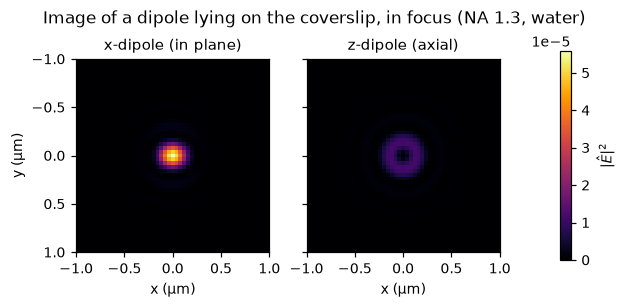

In [4]:
setup = dict(wavelength=517.5, na=1.3, pix_size=40.0, n_pix_psf=101, n_pix_pupil=201,
             n_s=1.33, n_g=1.5, n_i=1.5)      # water sample, glass coverslip, oil immersion

imager = SphericalDipoleImager(z_focus=0.0, **setup)
x = imager.x.numpy()                          # image grid in nanometer, in object space
centre = setup['n_pix_psf'] // 2

images = []
for dipole in [(1.0, 0.0, 0.0), (0.0, 0.0, 1.0)]:
    field = imager.compute_image(dipole=dipole, positions=(0.0, 0.0, 0.0))
    images.append((field.abs() ** 2).sum(dim=1)[0].numpy())

print('image field shape:', tuple(field.shape), '   E_z is zero:', bool(field[:, 2].abs().max() == 0))
show_maps(images, ['x-dipole (in plane)', 'z-dipole (axial)'], x, cmap='inferno', zoom=1.0,
          colorbar_label='$|\\hat{E}|^2$',
          suptitle='Image of a dipole lying on the coverslip, in focus (NA 1.3, water)')

### 1.3 The modality: `ISCATMicroscope`

`ScatteringMicroscope` composes a `Particle`, a plane-wave illumination and a dipole imager into the image on
the camera. Three subclasses fix the scheme:

| class | illumination reaching the particle | reference wave $\mathbf{E}^{\mathrm{ref}}$ |
|---|---|---|
| `ISCATMicroscope` | through the objective, $t_{ig}t_{gs}E^{0}$ | the illumination reflected at the coverslip-sample interface, $\beta\, t_{ig} r_{gs} t_{gi} E^{0}$ |
| `COBRIMicroscope` | from the sample side, $E^{0}$ | the transmitted illumination, $\beta\, t_{sg} t_{gi} E^{0}$ |
| `DarkFieldMicroscope` | as in iSCAT | none ($\beta = 0$) |

The imager is chosen by name (`imager='spherical'`, the default, or `'cartesian'`), as a parameter dictionary or
as an instance; every other keyword argument is forwarded to it. The methods are

| method | returns |
|---|---|
| `compute_image(positions)` | the camera intensity $\lvert E^{\mathrm{ref}} + E^{\mathrm{sca}}\rvert^{2}$, shape `(n_positions, n_pix, n_pix)` |
| `compute_contrast(positions)` | the iPSF $(I - I^{\mathrm{ref}})/I^{\mathrm{ref}}$, same shape |
| `compute_fields(positions)` | the reference vector `(3,)` and the scattered field `(n_positions, 3, n_pix, n_pix)` |
| `reference_intensity` | the background level $\lvert E^{\mathrm{ref}}\rvert^{2}$ |
| `polarizability()`, `excess_path()` | the polarizability in the sample medium, and the excess optical path $\Delta$ |
| `to_dict()` / `from_dict()`, `save_parameters()` / `load_parameters()` | the JSON round trip shared with the propagators |

Lengths are in nanometer and intensities in units of the incident intensity ($\lvert E^{0}\rvert = 1$), so the
contrast is directly comparable with an experiment.

In [5]:
iscat = ISCATMicroscope(gold, imager='spherical', z_focus=0.0, **setup)

print(f'modality               : {iscat.get_name()}  (imager: {type(iscat.imager).__name__})')
print(f'polarizability         : {iscat.polarizability():.4g} nm^3')
print(f'reference intensity    : {iscat.reference_intensity:.4g} x incident intensity')
print(f'excess optical path    : {iscat.excess_path():.4g} nm')
print(f'wavelength / NA / n_s  : {iscat.wavelength} nm / {iscat.imager.na} / {iscat.n_s}')

positions = [(0.0, 0.0, 0.0), (0.0, 0.0, 100.0), (200.0, 0.0, 100.0)]   # (x_p, y_p, z_p) in nm
reference, scattered = iscat.compute_fields(positions)
print()
print('reference field :', tuple(reference.shape), '   scattered field:', tuple(scattered.shape))
print('image           :', tuple(iscat.compute_image(positions).shape))
print('contrast        :', tuple(iscat.compute_contrast(positions).shape))

modality               : iscat  (imager: SphericalDipoleImager)
polarizability         : 4.809e+04+8.078e+04j nm^3
reference intensity    : 0.003608 x incident intensity
excess optical path    : 0 nm
wavelength / NA / n_s  : 517.5 nm / 1.3 / 1.33

reference field : (3,)    scattered field: (3, 3, 101, 101)
image           : (3, 101, 101)
contrast        : (3, 101, 101)


## 2. Anatomy of an image

The recorded intensity splits into three terms,

$$I = \underbrace{\lvert\mathbf{E}^{\mathrm{ref}}\rvert^{2}}_{\text{background}}
   + \underbrace{\lvert\mathbf{E}^{\mathrm{sca}}\rvert^{2}}_{\text{dark field}}
   + \underbrace{2\,\mathrm{Re}\!\left(\mathbf{E}^{\mathrm{ref}*}\cdot\mathbf{E}^{\mathrm{sca}}\right)}_{\text{interference}}.$$

The scattered intensity alone is tiny (it scales as the sixth power of the radius), but the cross term is only
*linear* in the scattered amplitude: this is what makes a 30 nm particle -- and, in mass photometry, a single
protein -- visible above a bright background.

background   |E_ref|^2        = 3.608e-03
dark field   max |E_sca|^2    = 2.386e-04
interference max |2 Re(...)|  = 1.595e-03  (7 x the dark-field term)
peak contrast                 = 0.508


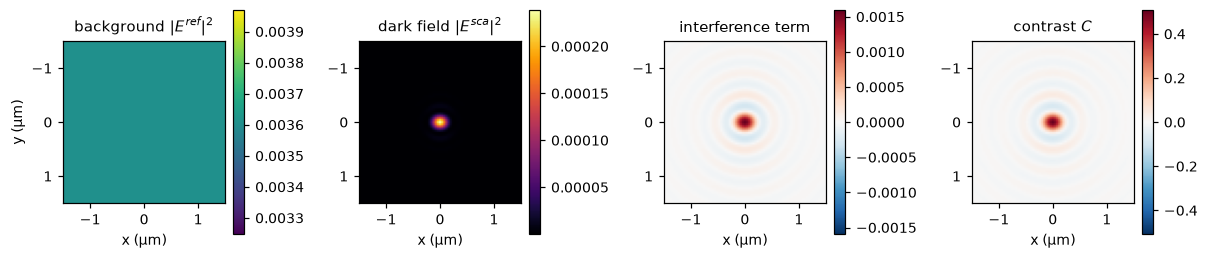

In [6]:
position = (0.0, 0.0, 0.0)      # the particle sits on the coverslip, in focus
reference, scattered = iscat.compute_fields(position)
dark_field = (scattered.abs() ** 2).sum(dim=1)[0]
interference = 2.0 * (reference[None, :, None, None].conj() * scattered).real.sum(dim=1)[0]
contrast = iscat.compute_contrast(position)[0]

print(f'background   |E_ref|^2        = {iscat.reference_intensity:.3e}')
print(f'dark field   max |E_sca|^2    = {float(dark_field.max()):.3e}')
print(f'interference max |2 Re(...)|  = {float(interference.abs().max()):.3e}  '
      f'({float(interference.abs().max() / dark_field.max()):.0f} x the dark-field term)')
print(f'peak contrast                 = {float(contrast.abs().max()):.3f}')

panels = [(np.full(dark_field.shape, iscat.reference_intensity), 'background $|E^{ref}|^2$', 'viridis'),
          (dark_field.numpy(), 'dark field $|E^{sca}|^2$', 'inferno'),
          (interference.numpy(), 'interference term', 'RdBu_r'),
          (contrast.numpy(), 'contrast $C$', 'RdBu_r')]
extent = np.array([x[0], x[-1], x[-1], x[0]]) / 1e3
fig, axes = plt.subplots(1, 4, figsize=(11, 2.8), constrained_layout=True)
for ax, (image, title, cmap) in zip(axes, panels):
    limit = float(np.abs(image).max())
    kwargs = dict(vmin=-limit, vmax=limit) if cmap == 'RdBu_r' else {}
    handle = ax.imshow(image, extent=extent, cmap=cmap, **kwargs)
    ax.set_title(title)
    ax.set_xlabel('x (µm)')
    ax.set_xlim(-1.5, 1.5), ax.set_ylim(1.5, -1.5)
    fig.colorbar(handle, ax=ax, shrink=0.75)
axes[0].set_ylabel('y (µm)')
plt.show()

Two phases decide how much of the scattered light is actually seen. The imaging integral carries the prefactor
$-\mathrm{i}k_i$ of Debye and Wolf, so with a design coverslip and immersion the scattered light reaches the
camera *in quadrature* with the reference: a particle whose polarizability is real and that sits exactly in the
focal plane produces no contrast at all (we come back to this with a protein in section 5). Gold at 517.5 nm is
close to its plasmon resonance and its polarizability has a large imaginary part, which is why the image above
already shows 50 % contrast. The second phase is geometric -- the defocus and the height of the particle -- and
it is the subject of the next section.

## 3. Defocus

Two independent axial coordinates enter an iSCAT image:

* `z_focus`, where the objective is focused -- a property of the microscope, so a new value means a new
  `ISCATMicroscope` (it changes the thickness $t_i$ of the immersion layer);
* `z_p`, the height of the particle above the coverslip -- an argument of `compute_image` / `compute_contrast`,
  so a whole stack of heights is computed in one call.

They do *not* play symmetric roles. Moving the focus changes the aberration of the collected wavefront (the
usual defocus of a PSF), whereas moving the particle changes the illumination path as well: the light travels
down to the particle and back before interfering with the reference, so the phase of the signal advances by
$2 k n_s z_p$.

### 3.1 Scanning the focus

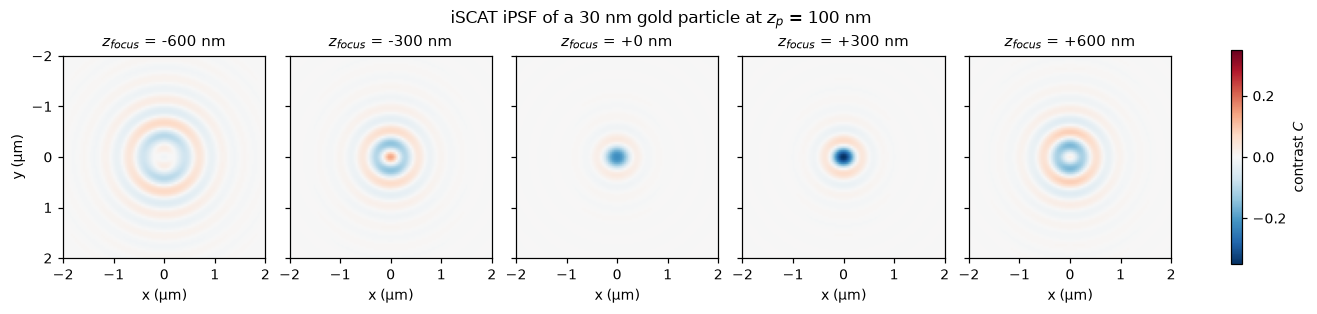

on-axis contrast: -0.011, +0.140, -0.220, -0.351, +0.017


In [7]:
focus_positions = [-600.0, -300.0, 0.0, 300.0, 600.0]     # nm, focal plane above the coverslip
height = 100.0                                            # the particle rests on the coverslip

contrasts = []
for z_focus in focus_positions:
    microscope = ISCATMicroscope(gold, z_focus=z_focus, **setup)
    contrasts.append(microscope.compute_contrast((0.0, 0.0, height))[0].numpy())

show_maps(contrasts, [f'$z_{{focus}}$ = {z:+.0f} nm' for z in focus_positions], x,
          colorbar_label='contrast $C$',
          suptitle=f'iSCAT iPSF of a 30 nm gold particle at $z_p$ = {height:.0f} nm')
print('on-axis contrast:', ', '.join(f'{c[centre, centre]:+.3f}' for c in contrasts))

The iPSF is not a defocused intensity PSF: it is an *interference* pattern, so it changes sign and its rings
invert as the focus crosses the particle. This asymmetry about the focus is the reason iSCAT can localize a
particle axially, and the reason the contrast of an experiment depends critically on the focus setting.

### 3.2 Through-focus section

The centre line of the images above, as a function of the focus position:

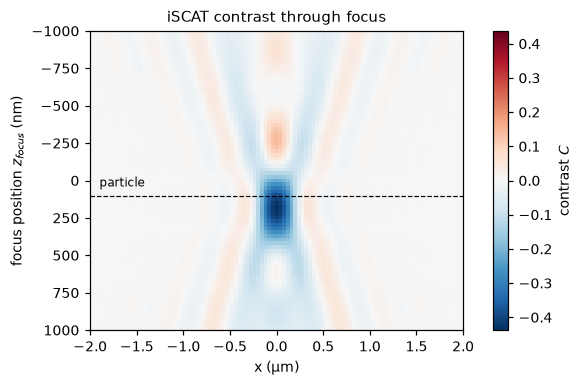

In [8]:
focus_scan = np.linspace(-1000.0, 1000.0, 81)
section = np.stack([ISCATMicroscope(gold, z_focus=float(z_focus), **setup)
                    .compute_contrast((0.0, 0.0, height))[0, centre].numpy() for z_focus in focus_scan])

limit = np.abs(section).max()
fig, ax = plt.subplots(figsize=(5.2, 3.4), constrained_layout=True)
handle = ax.imshow(section, cmap='RdBu_r', vmin=-limit, vmax=limit, aspect='auto',
                   extent=[x[0] / 1e3, x[-1] / 1e3, focus_scan[-1], focus_scan[0]])
ax.axhline(height, color='k', lw=0.8, ls='--')
ax.text(x[0] / 1e3 + 0.1, height - 60, 'particle', fontsize=8)
ax.set_xlabel('x (µm)')
ax.set_ylabel('focus position $z_{focus}$ (nm)')
ax.set_title('iSCAT contrast through focus')
fig.colorbar(handle, ax=ax, label='contrast $C$')
plt.show()

### 3.3 Moving the particle

With the focus fixed, the contrast of a particle moving away from the coverslip oscillates with the period
$\lambda / 2 n_s$ -- the round trip of the illumination down to the particle and back -- inside an envelope set
by the defocus. This is the fast fringe that iSCAT tracking exploits to follow a particle in three dimensions,
and it is absent in COBRI, where the reference is transmitted rather than reflected (section 5).

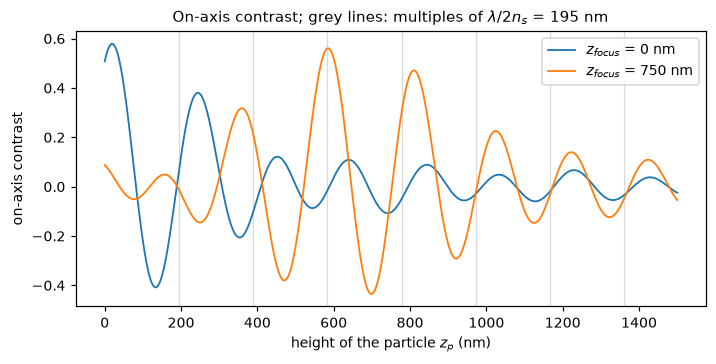

In [9]:
heights = torch.linspace(0.0, 1500.0, 601)
positions = torch.stack([torch.zeros_like(heights), torch.zeros_like(heights), heights], dim=1)

on_axis = {z_focus: ISCATMicroscope(gold, z_focus=z_focus, **setup)
           .compute_contrast(positions)[:, centre, centre].numpy() for z_focus in (0.0, 750.0)}

fig, ax = plt.subplots(figsize=(6.4, 3.2), constrained_layout=True)
for z_focus, curve in on_axis.items():
    ax.plot(heights.numpy(), curve, lw=1.2, label=f'$z_{{focus}}$ = {z_focus:.0f} nm')
period = iscat.wavelength / (2 * iscat.n_s)
for n in range(1, int(heights[-1] / period) + 1):
    ax.axvline(n * period, color='0.85', lw=0.8, zorder=0)
ax.set_xlabel('height of the particle $z_p$ (nm)')
ax.set_ylabel('on-axis contrast')
ax.set_title(f'On-axis contrast; grey lines: multiples of $\\lambda/2n_s$ = {period:.0f} nm')
ax.legend()
plt.show()

## 4. Simpler models of the detection path

The imaging integral of the dipole imagers keeps everything: the vectorial radiation pattern of the dipole, the
Fresnel coefficients of the two interfaces (including the evanescent components beyond the critical angle), the
optical path through the layers and the apodization of the objective. Each of these can be dropped, and the
library lets you do it one ingredient at a time. This section compares the models on the same particle.

### 4.1 Two quadratures of the same integral

`SphericalDipoleImager` and `CartesianDipoleImager` evaluate the *same* integral. The spherical one integrates
over the polar angle only (the azimuth is done analytically with Bessel functions), which is several times
cheaper; the Cartesian one samples the pupil on a square grid, so the disc of the pupil is discretized
and the residual difference decreases as $1/n_{\mathrm{pix\,pupil}}$. Use the Cartesian imager when the pupil is
not axisymmetric -- astigmatism, coma, a phase mask -- which the spherical imager cannot represent (it warns and
ignores those modes).

In [10]:
positions = [(0.0, 0.0, z) for z in (0.0, 250.0, 500.0)]
fields = {}
for name, imager_type in [('spherical', SphericalDipoleImager), ('cartesian', CartesianDipoleImager)]:
    current = imager_type(z_focus=0.0, **setup)
    current.compute_image((1.0, 0.0, 0.0), positions)                   # warm-up
    start = time.perf_counter()
    fields[name] = current.compute_image((1.0, 0.0, 0.0), positions)
    print(f'{name:<10} {1e3 * (time.perf_counter() - start):6.1f} ms for {len(positions)} positions')

difference = (fields['spherical'] - fields['cartesian']).abs().max() / fields['spherical'].abs().max()
print(f'\nmaximum relative difference between the two: {float(difference):.1e}')

spherical     2.2 ms for 3 positions
cartesian    15.1 ms for 3 positions

maximum relative difference between the two: 1.1e-03


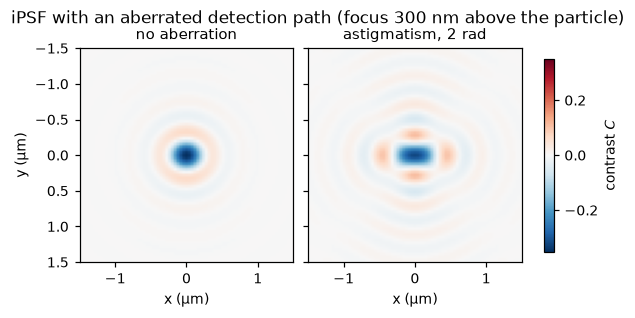

In [11]:
# An astigmatic detection path (OSA index 5), which only the Cartesian imager can apply.
aberrated = ISCATMicroscope(gold, imager='cartesian', zernike_coefficients=[0, 0, 0, 0, 0, 2.0],
                            z_focus=300.0, **setup)
diffraction_limited = ISCATMicroscope(gold, imager='cartesian', z_focus=300.0, **setup)

show_maps([diffraction_limited.compute_contrast((0.0, 0.0, height))[0].numpy(),
           aberrated.compute_contrast((0.0, 0.0, height))[0].numpy()],
          ['no aberration', 'astigmatism, 2 rad'], x, colorbar_label='contrast $C$', zoom=1.5,
          suptitle='iPSF with an aberrated detection path (focus 300 nm above the particle)')

### 4.2 What the interfaces are worth

The `fresnel` argument of the imagers selects how the light radiated by the dipole is transmitted through the
sample-coverslip-immersion stack:

* `'reciprocal'` (the default, and the physical one): the far field in the immersion medium is
  $t_{s\to i}\, n_i\cos\theta/(n_s\cos\theta_s)$ times the far field in the sample, and that geometric factor
  turns the coefficients into those of the *reverse* direction, $t_{i \to s}$ (Novotny & Hecht, Eqs. 10.36-10.38).
  It weights the high angles up, towards the critical angle;
* `'forward'`: the forward coefficients $t_{s\to i}$ alone, the convention of Mahmoodabadi et al. (2020) and
  Dong et al. (2021);
* `'none'`: no coefficients at all -- the interfaces only bend the rays and add the optical path.

The three models differ by about 10 % in the *absolute* contrast for this geometry, and by more for a particle
further from the coverslip -- which matters whenever the contrast is used to infer a size or a mass -- while the
shape of the iPSF is almost untouched.

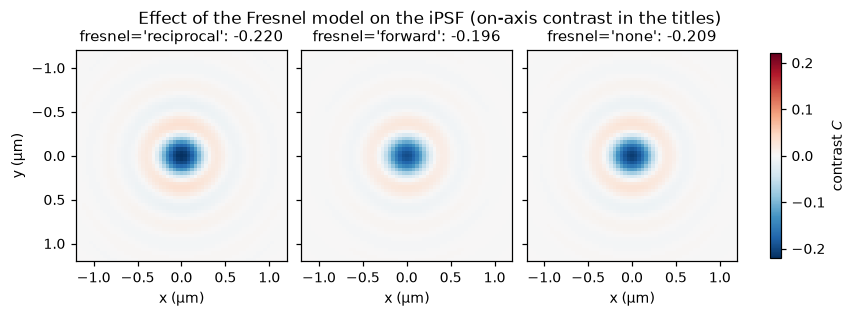

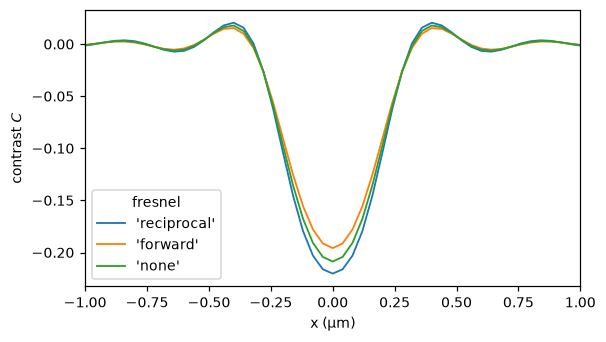

'forward': peak contrast -11 % relative to the physical model, residual shape difference 3.7 % after rescaling
'none': peak contrast -5 % relative to the physical model, residual shape difference 1.8 % after rescaling


In [12]:
modes = ('reciprocal', 'forward', 'none')
contrasts, titles = [], []
for mode in modes:
    microscope = ISCATMicroscope(gold, z_focus=0.0, fresnel=mode, **setup)
    contrast = microscope.compute_contrast((0.0, 0.0, height))[0]
    contrasts.append(contrast.numpy())
    titles.append(f"fresnel='{mode}': {float(contrast[centre, centre]):+.3f}")
show_maps(contrasts, titles, x, colorbar_label='contrast $C$', zoom=1.2,
          suptitle='Effect of the Fresnel model on the iPSF (on-axis contrast in the titles)')

fig, ax = plt.subplots(figsize=(5.4, 3.0), constrained_layout=True)
for mode, contrast in zip(modes, contrasts):
    ax.plot(x / 1e3, contrast[centre], lw=1.2, label=f"'{mode}'")
ax.set_xlabel('x (µm)'), ax.set_ylabel('contrast $C$'), ax.legend(title='fresnel')
ax.set_xlim(-1.0, 1.0)
plt.show()

reference = contrasts[0]
for mode, contrast in zip(modes[1:], contrasts[1:]):
    ratio = np.abs(contrast).max() / np.abs(reference).max()
    shape = np.abs(contrast / ratio - reference).max() / np.abs(reference).max()
    print(f"'{mode}': peak contrast {100 * (ratio - 1):+.0f} % relative to the physical model, "
          f'residual shape difference {100 * shape:.1f} % after rescaling')

### 4.3 Back to the propagators: how simple can the detection PSF be?

The imaging integral and the focusing integral of the propagators are the same Debye-Wolf integral run in
opposite directions, and in a *homogeneous* sample (no index mismatch, no interfaces left) they coincide: the
image of a dipole is the focus field of the matching vectorial propagator with `apod_factor=True`, up to a
constant that only reflects a different normalization of the pupil. A dipole at height `z_p` corresponds to the
focus field at defocus `z_p - z_focus`.

That equality is what lets you replace the imager with a cheaper model, and it also says what you lose: the
**scalar** propagator ignores the polarization of the dipole and the mixing of the components in the pupil, and
returns a rotationally symmetric PSF, whereas the image of an x-oriented dipole is elongated along x at high NA.

In [13]:
homogeneous = dict(setup, n_s=1.5, pix_size=20.0)       # index-matched sample: no interface left
focus_depth, defocus = 400.0, 400.0
heights_matched = [(0.0, 0.0, focus_depth + dz) for dz in (-defocus, 0.0, defocus)]

imager_matched = SphericalDipoleImager(z_focus=focus_depth, **homogeneous)
image = imager_matched.compute_image(dipole=(1.0, 0.0, 0.0), positions=heights_matched)

vectorial = VectorialSphericalPropagator(**homogeneous, apod_factor=True, e0x=1.0, e0y=0.0,
                                         defocus_step=defocus, n_defocus=3).compute_focus_field()
scalar = ScalarSphericalPropagator(**homogeneous, apod_factor=True,
                                   defocus_step=defocus, n_defocus=3).compute_focus_field()


def match_scale(target, model):
    """Complex constant c minimising ||target - c * model||: the propagators normalise the pupil differently."""
    return (model.conj() * target).sum() / (model.abs() ** 2).sum()


for name, model in [('vectorial propagator', vectorial[:, :2]), ('scalar propagator', scalar[:, :1])]:
    target = image[:, :2] if 'vectorial' in name else image[:, :1]
    scaled = match_scale(target, model) * model
    print(f'{name:<22} max relative difference with the imager: '
          f'{float((target - scaled).abs().max() / target.abs().max()):.1e}')

vectorial propagator   max relative difference with the imager: 5.4e-07
scalar propagator      max relative difference with the imager: 9.0e-02


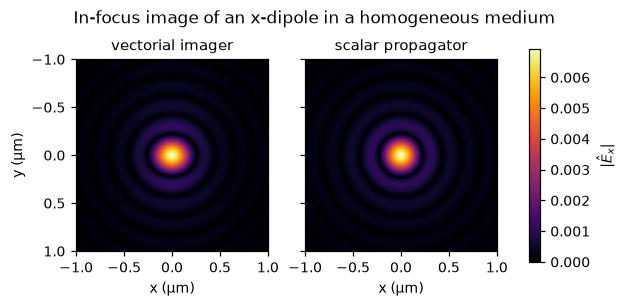

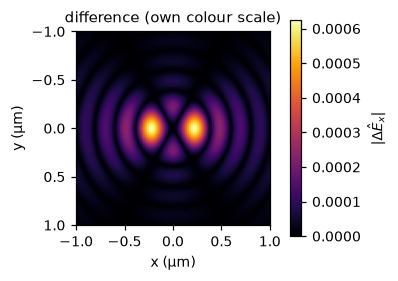

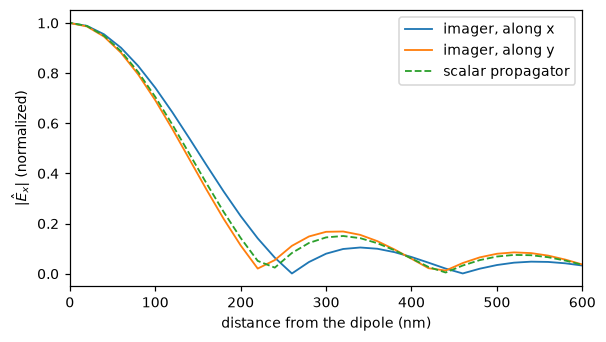

In [14]:
x_matched = imager_matched.x.numpy()
centre_matched = homogeneous['n_pix_psf'] // 2
exact = image[1, 0]                                             # in-focus, x component
approximate = match_scale(image[:, :1], scalar[:, :1]) * scalar[1, 0]

show_maps([exact.abs().numpy(), approximate.abs().numpy()], ['vectorial imager', 'scalar propagator'],
          x_matched, cmap='inferno', colorbar_label='$|\\hat{E}_x|$',
          suptitle='In-focus image of an x-dipole in a homogeneous medium')
show_maps([(exact - approximate).abs().numpy()], ['difference (own colour scale)'], x_matched, cmap='inferno',
          colorbar_label='$|\\Delta\\hat{E}_x|$')

fig, ax = plt.subplots(figsize=(5.4, 3.0), constrained_layout=True)
for label, profile, style in [('imager, along x', exact.abs()[centre_matched, :], '-'),
                              ('imager, along y', exact.abs()[:, centre_matched], '-'),
                              ('scalar propagator', approximate.abs()[centre_matched, :], '--')]:
    ax.plot(x_matched, profile.numpy() / float(exact.abs().max()), style, lw=1.2, label=label)
ax.set_xlim(0, 600), ax.set_xlabel('distance from the dipole (nm)'), ax.set_ylabel('$|\\hat{E}_x|$ (normalized)')
ax.legend()
plt.show()

The vectorial image is elongated along the dipole axis: its section along x is wider than the one along y, and
its first zero sits further out. The scalar PSF is rotationally symmetric by construction: it follows the narrow
(y) section closely and misses the elongation altogether, which is the 9 % left over by the fit above.

An interferometric image is *linear* in the scattered field, so that error carries straight over to the iPSF --
and it is amplified out of focus, where the iPSF is a weak ring pattern. The comparison below reuses the public
interface of the modality (`reference_field()` plus a scattered field of our own), which is also the recipe for
writing a modality of your own.

           plane   peak |C|   max error   relative
 defocus -400 nm     0.0110      0.0086       78%
        in focus     0.0354      0.0108       31%
 defocus +400 nm     0.0110      0.0120      109%


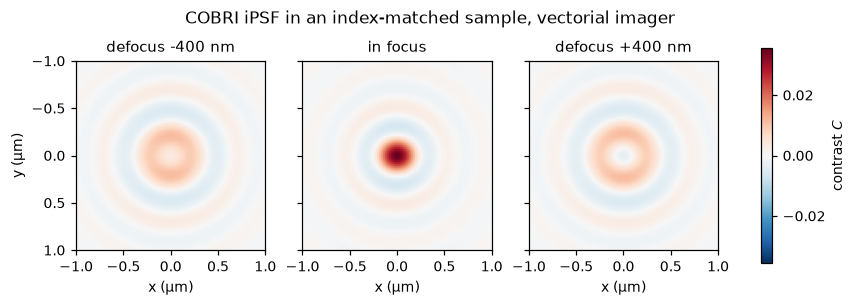

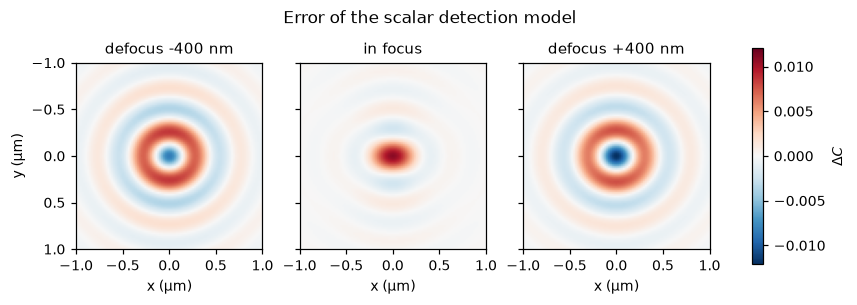

In [15]:
def contrast_from_scattered(microscope, scattered):
    """iPSF of a scattered field computed by hand: the recipe used by `compute_contrast`."""
    reference = microscope.reference_field()
    total = reference[None, :, None, None] + scattered
    return ((total.abs() ** 2).sum(dim=1) - microscope.reference_intensity) / microscope.reference_intensity


# COBRI in the index-matched sample: the reference is the transmitted illumination, so the contrast is defined
# (in iSCAT the reference is the reflection at the coverslip, which vanishes without an index step).
matched = COBRIMicroscope(gold, z_focus=focus_depth, **homogeneous)
reference, scattered = matched.compute_fields(heights_matched)

scalar_scattered = torch.zeros_like(scattered)
scalar_scattered[:, 0] = match_scale(scattered[:, :1], scalar[:, :1]) * scalar[:, 0]

exact_contrast = matched.compute_contrast(heights_matched)
scalar_contrast = contrast_from_scattered(matched, scalar_scattered)

labels = ['defocus -400 nm', 'in focus', 'defocus +400 nm']
print(f'{"plane":>16} {"peak |C|":>10} {"max error":>11} {"relative":>10}')
for label, exact_plane, scalar_plane in zip(labels, exact_contrast, scalar_contrast):
    peak = float(exact_plane.abs().max())
    error = float((exact_plane - scalar_plane).abs().max())
    print(f'{label:>16} {peak:10.4f} {error:11.4f} {error / peak:9.0%}')

show_maps([c.numpy() for c in exact_contrast], labels, x_matched, colorbar_label='contrast $C$',
          suptitle='COBRI iPSF in an index-matched sample, vectorial imager')
show_maps([(a - b).numpy() for a, b in zip(exact_contrast, scalar_contrast)], labels, x_matched,
          colorbar_label='$\\Delta C$', suptitle='Error of the scalar detection model')

## 5. The other coherent modalities

iSCAT, COBRI and dark field share the same detection path and differ by the reference wave and by the path the
illumination takes to the particle. The three classes take exactly the same arguments, and the difference shows
up in the background level and in the contrast.

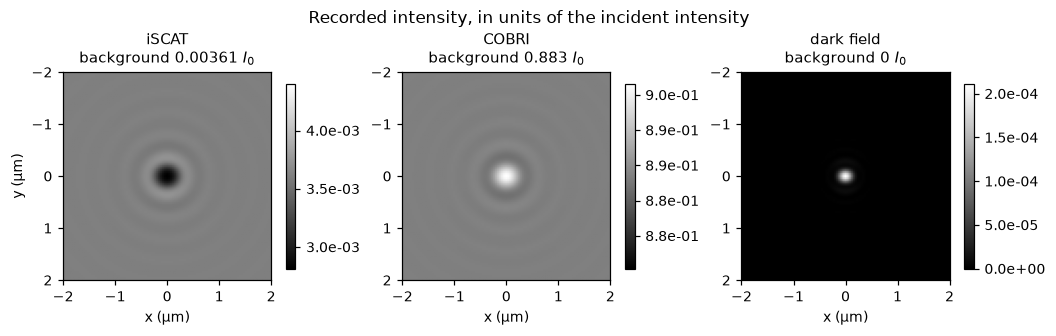

iSCAT       background 3.608e-03   peak modulation 7.947e-04   peak contrast 0.220
COBRI       background 8.835e-01   peak modulation 1.313e-02   peak contrast 0.015
dark field  background 0.000e+00   peak modulation 2.115e-04   


In [16]:
microscopes = {'iSCAT': ISCATMicroscope(gold, z_focus=0.0, **setup),
               'COBRI': COBRIMicroscope(gold, z_focus=0.0, **setup),
               'dark field': DarkFieldMicroscope(gold, z_focus=0.0, **setup)}

fig, axes = plt.subplots(1, 3, figsize=(9.5, 2.9), constrained_layout=True)
extent = np.array([x[0], x[-1], x[-1], x[0]]) / 1e3
for ax, (name, microscope) in zip(axes, microscopes.items()):
    image = microscope.compute_image((0.0, 0.0, height))[0].numpy()
    background = microscope.reference_intensity
    spread = np.abs(image - background).max()
    handle = ax.imshow(image, extent=extent, cmap='gray',
                       vmin=max(background - spread, 0.0), vmax=background + spread)
    ax.set_title(f'{name}\nbackground {background:.3g} $I_0$')
    ax.set_xlabel('x (µm)')
    fig.colorbar(handle, ax=ax, shrink=0.8, format='%.1e')
axes[0].set_ylabel('y (µm)')
fig.suptitle('Recorded intensity, in units of the incident intensity')
plt.show()

for name, microscope in microscopes.items():
    image = microscope.compute_image((0.0, 0.0, height))[0]
    modulation = float((image - microscope.reference_intensity).abs().max())
    print(f'{name:<11} background {microscope.reference_intensity:.3e}   '
          f'peak modulation {modulation:.3e}   '
          + ('' if name == 'dark field' else f'peak contrast {modulation / microscope.reference_intensity:.3f}'))

Dark field has no background at all, so nothing has to be subtracted, but what it records is
$\lvert E^{\mathrm{sca}}\rvert^{2}$ -- four orders of magnitude below the incident intensity here, and falling
as the sixth power of the radius. That is what makes small particles vanish in dark field while they stay
visible in the interferometric schemes.

The two interferometric schemes also behave differently along the axis: the iSCAT reference is reflected at the
coverslip *below* the particle, so the signal oscillates with the height of the particle, whereas the COBRI
reference is transmitted and the two paths stay in step.

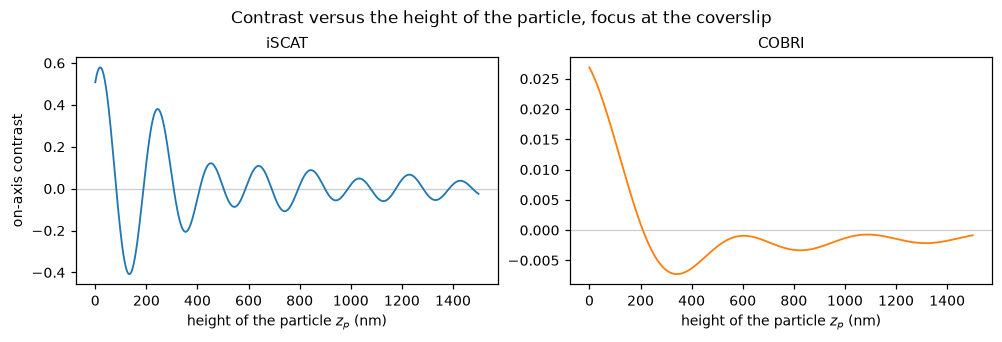

In [17]:
positions_height = torch.stack([torch.zeros_like(heights), torch.zeros_like(heights), heights], dim=1)

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.0), constrained_layout=True, sharex=True)
for ax, name in zip(axes, ('iSCAT', 'COBRI')):
    curve = microscopes[name].compute_contrast(positions_height)[:, centre, centre]
    ax.plot(heights.numpy(), curve.numpy(), lw=1.2, color='C0' if name == 'iSCAT' else 'C1')
    ax.set_title(name), ax.set_xlabel('height of the particle $z_p$ (nm)')
    ax.axhline(0.0, color='0.8', lw=0.8, zorder=0)
axes[0].set_ylabel('on-axis contrast')
fig.suptitle('Contrast versus the height of the particle, focus at the coverslip')
plt.show()

### Attenuating the reference

A partial reflector in the back focal plane attenuates the reference by $\beta$ (`attenuation`) without touching
the scattered light. The interference term then grows as $1/\beta$ and the dark-field term as $1/\beta^{2}$, so
attenuating the reference raises the contrast until the scattered intensity takes over and the microscope turns
into an (inefficient) dark-field one -- `attenuation=0` *is* dark field, which is why `DarkFieldMicroscope` is
the same class with $\beta = 0$. The gain in an experiment is in the signal-to-noise ratio: the camera well is
filled by the reference, so attenuating it and raising the illumination in the same proportion keeps the same
background with many more scattered photons.

In [18]:
attenuations = [1.0, 0.5, 0.2, 0.1, 0.05]
print(f'{"beta":>6} {"background":>12} {"interference":>14} {"dark field":>12} {"total |C|":>11}')
for attenuation in attenuations:
    microscope = ISCATMicroscope(gold, attenuation=attenuation, z_focus=0.0, **setup)
    reference, scattered = microscope.compute_fields((0.0, 0.0, height))
    interference = 2.0 * (reference[None, :, None, None].conj() * scattered).real.sum(dim=1)
    dark_field = (scattered.abs() ** 2).sum(dim=1)
    total = microscope.compute_contrast((0.0, 0.0, height))
    print(f'{attenuation:6.2f} {microscope.reference_intensity:12.3e} '
          f'{float(interference.abs().max()) / microscope.reference_intensity:14.3f} '
          f'{float(dark_field.max()) / microscope.reference_intensity:12.3f} '
          f'{float(total.abs().max()):11.3f}')

  beta   background   interference   dark field   total |C|
  1.00    3.608e-03          0.279        0.059       0.220
  0.50    9.021e-04          0.558        0.234       0.330
  0.20    1.443e-04          1.394        1.465       0.524
  0.10    3.608e-05          2.788        5.861       3.073
  0.05    9.021e-06          5.577       23.446      17.869


### Mass photometry

A protein is not a metal nanoparticle: it is small and its polarizability is *real*, so -- as announced in
section 2 -- a molecule lying on the coverslip is invisible when the objective is focused on the coverslip, and
the signal has to be brought out of quadrature by focusing a few hundred nanometers away. With the focus set,
`Particle.from_mass` and the same iSCAT model give the calibration curve of mass photometry: a contrast
proportional to the mass of the molecule, here 0.016 % per 100 kDa.

100 kDa protein on the coverslip, objective focused on the coverslip: contrast = 0.0e+00


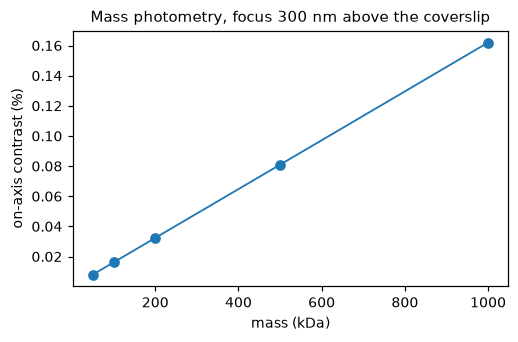

contrast per 100 kDa: 0.016 %


In [19]:
in_focus = ISCATMicroscope(protein, z_focus=0.0, **setup)
print('100 kDa protein on the coverslip, objective focused on the coverslip: '
      f'contrast = {float(in_focus.compute_contrast((0.0, 0.0, 0.0))[0, centre, centre]):.1e}')

masses = np.array([50.0, 100.0, 200.0, 500.0, 1000.0])       # kDa
contrasts_mass = []
for mass in masses:
    molecule = Particle.from_mass(mass=float(mass), density=1.35, refractive_index=1.59)
    microscope = ISCATMicroscope(molecule, z_focus=300.0, **setup)
    contrasts_mass.append(float(microscope.compute_contrast((0.0, 0.0, 0.0))[0, centre, centre]))

fig, ax = plt.subplots(figsize=(4.6, 3.0), constrained_layout=True)
ax.plot(masses, 100 * np.array(contrasts_mass), 'o-', lw=1.2)
ax.set_xlabel('mass (kDa)'), ax.set_ylabel('on-axis contrast (%)')
ax.set_title('Mass photometry, focus 300 nm above the coverslip')
plt.show()
print(f'contrast per 100 kDa: {1e4 * np.polyfit(masses, contrasts_mass, 1)[0]:.3f} %')

## 6. Saving the parameters

Every model of the library -- propagators, imagers and modalities alike -- is fully described by its constructor
arguments and can be written to JSON and read back, imager included. Loading through the abstract base class
recovers the right subclass from the registry.

In [20]:
with tempfile.TemporaryDirectory() as directory:
    path = os.path.join(directory, 'iscat.json')
    iscat.save_parameters(path)
    restored = Modality.load_parameters(path)

print(type(restored).__name__, '|', restored.to_dict() == iscat.to_dict())
print('same iPSF:', torch.allclose(restored.compute_contrast((0.0, 0.0, height)),
                                   iscat.compute_contrast((0.0, 0.0, height))))

ISCATMicroscope | True
same iPSF: True


## Where to go next

* the theory page *Imaging a Dipole: the Detection Path* derives the imaging integral, the reciprocity relation
  used in section 4.3 and the phase conventions of the three schemes, and relates the model to the published
  iSCAT models (Mahmoodabadi et al. 2020, Dong et al. 2021, Hitzelhammer et al. 2024);
* `demos/scripts/iscat_demo.py` produces a compact set of the same figures outside a notebook;
* a `Modality` is just a class that returns an image: combining a propagator (excitation), a dipole imager
  (detection) and a detector model is all that a confocal or image-scanning modality needs, and the parameter
  round trip, the registry and the batching over positions come for free from the base classes.